# **Capstone Project**
Submitted by - **Mohammad Daarim Javed**

Submitted to - **Mustafa Hasan Sir**

Roll No - **J240212046**

Branch - **CSEDS**

---



###Task 1: Fetch Stock Data

In [231]:
# Importing the required libraries
import pandas as pd
import numpy as np
import yfinance as yf


In [232]:
# Defining assets
assets = [
    "^BSESN",
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS"
]

In [237]:
# Downloading all the stocks using for loop

stock_data = {}

for ticker in assets:

    df = yf.download(ticker, period="5y")

    # Flatten MultiIndex columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Convert index into Date column
    df = df.reset_index()

    # Save clean CSV
    df.to_csv(f"data_{ticker}.csv", index=False)

    # Store the DataFrame in the stock_data dictionary
    stock_data[ticker] = df

print("All files saved successfully!")

/tmp/ipykernel_618/2726455205.py:7: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_618/2726455205.py:7: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_618/2726455205.py:7: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_618/2726455205.py:7: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_618/2726455205.py:7: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

All files saved successfully!


In [238]:
# Verification
print(stock_data.keys())

dict_keys(['^BSESN', 'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS'])


In [239]:
# Checking one stock if everything is fine or not
stock_data["RELIANCE.NS"].head()

Price,Date,Close,High,Low,Open,Volume
0,2021-07-26,940.642639,960.638932,938.038360,954.751045,12389668
1,2021-07-27,930.746338,943.745093,924.858451,940.619982,10824523
2,2021-07-28,922.752258,932.105009,913.195667,932.105009,12897848
3,2021-07-29,929.953674,939.532908,925.492430,930.293368,13765738
4,2021-07-30,921.823853,936.611585,919.921543,932.105057,11350608


###Task 2: Fetch News Data

In [240]:
# Importing the required library

import requests


In [241]:
# Storing API Key

from google.colab import userdata
NEWS_API_KEY = userdata.get('NewsAPI')

In [242]:
company_names = {
    "^BSESN": "BSE Sensex",
    "RELIANCE.NS": "Reliance Industries",
    "TCS.NS": "Tata Consultancy Services",
    "INFY.NS": "Infosys",
    "HDFCBANK.NS": "HDFC Bank"
}

In [243]:
# Defining the Fetch Function

def fetch_news(company):

    url = "https://newsapi.org/v2/everything"

    params = {
        "q": f'"{company}"',
        "language": "en",
        "sortBy": "publishedAt",
        "pageSize": 20,
        "searchIn": "title,description",
        "apiKey": NEWS_API_KEY
    }

    response = requests.get(url, params=params)

    return response.json()

In [244]:
# Testing the Function

news = fetch_news("Reliance Industries")

print(news["status"])

ok


In [245]:
# Fetching News for All 5 Companies

all_news = {}

for ticker, company in company_names.items():

    print(f"Fetching news for {company}...")

    news = fetch_news(company)

    all_news[ticker] = news

print("News fetched successfully!")

Fetching news for BSE Sensex...
Fetching news for Reliance Industries...
Fetching news for Tata Consultancy Services...
Fetching news for Infosys...
Fetching news for HDFC Bank...
News fetched successfully!


In [246]:
# Checking Whether the News Was Downloaded

print(all_news.keys())

dict_keys(['^BSESN', 'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS'])


In [247]:
# Saving the News as CSV Files

for ticker, news_data in all_news.items():

    articles = news_data.get("articles", [])

    if len(articles) == 0:
        print(f"No news found for {ticker}")
        continue

    news_df = pd.DataFrame(articles)

    filename = f"news_{ticker}.csv"

    news_df.to_csv(filename, index=False)

    print(f"{filename} saved successfully.")

news_^BSESN.csv saved successfully.
news_RELIANCE.NS.csv saved successfully.
news_TCS.NS.csv saved successfully.
news_INFY.NS.csv saved successfully.
news_HDFCBANK.NS.csv saved successfully.


In [248]:
# Verifying One CSV

reliance_news = pd.read_csv("news_RELIANCE.NS.csv")

reliance_news.head(3)

,source,author,title,description,url,urlToImage,publishedAt,content
0,"{'id': 'the-times-of-india', 'name': 'The Time...",Nikhil Agarwal,Mukesh Ambani’s long game: How Reliance could ...,Reliance Industries could generate nearly Rs 9...,https://economictimes.indiatimes.com/markets/s...,"https://img.etimg.com/thumb/msid-132597211,wid...",2026-07-24T05:29:02Z,Billionaire Mukesh Ambanis three-year investme...
1,"{'id': None, 'name': 'Economictimes.com'}",IANS,"12 stocks that Goldman Sachs, Axis, InCred Equ...",Leading brokerage firms have identified twelve...,https://m.economictimes.com/markets/stocks/new...,"https://img.etimg.com/thumb/msid-132571220,wid...",2026-07-23T03:17:48Z,"Jul 23, 2026, 08:54:01 AM IST\r\nWith the Nift..."
2,"{'id': 'the-times-of-india', 'name': 'The Time...",Debaroti Adhikary,Market wrap: Top gainers and losers on Nifty a...,Indian benchmark indices extended losses on Tu...,https://economictimes.indiatimes.com/markets/s...,"https://img.etimg.com/thumb/msid-132535007,wid...",2026-07-21T11:24:15Z,The Indian stock market extended losses on Tue...


###Task 3: Clean the Data

In [249]:
# Cleaning the Stock Data

for ticker, df in stock_data.items():

    print(f"\nCleaning {ticker}...")

    # Flattening MultiIndex columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Converting index to datetime
    df.index = pd.to_datetime(df.index)

    # Checking missing values
    print("Missing Values:")
    print(df.isnull().sum())

    # Dropping missing values
    df.dropna(inplace=True)

    # Saving cleaned dataframe back
    stock_data[ticker] = df

print("\nStock data cleaned successfully!")


Cleaning ^BSESN...
Missing Values:
Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Cleaning RELIANCE.NS...
Missing Values:
Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Cleaning TCS.NS...
Missing Values:
Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Cleaning INFY.NS...
Missing Values:
Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Cleaning HDFCBANK.NS...
Missing Values:
Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Stock data cleaned successfully!


In [250]:
# Verifying One Stock

stock_data["RELIANCE.NS"].head()

Price,Date,Close,High,Low,Open,Volume
1970-01-01 00:00:00.000000000,2021-07-26,940.642639,960.638932,938.038360,954.751045,12389668
1970-01-01 00:00:00.000000001,2021-07-27,930.746338,943.745093,924.858451,940.619982,10824523
1970-01-01 00:00:00.000000002,2021-07-28,922.752258,932.105009,913.195667,932.105009,12897848
1970-01-01 00:00:00.000000003,2021-07-29,929.953674,939.532908,925.492430,930.293368,13765738
1970-01-01 00:00:00.000000004,2021-07-30,921.823853,936.611585,919.921543,932.105057,11350608


In [251]:
# Reading the News CSV Files
# We need to clean the news data as well

news_data = {}

for ticker in assets:

    filename = f"news_{ticker}.csv"

    df = pd.read_csv(filename)

    news_data[ticker] = df

print("News files loaded successfully!")

News files loaded successfully!


In [252]:
# Cleaning the news data

for ticker, df in news_data.items():

    print(f"\nCleaning news for {ticker}...")

    # Missing values
    print(df.isnull().sum())

    # Convert published date
    if "publishedAt" in df.columns:
        df["publishedAt"] = pd.to_datetime(df["publishedAt"])

    # Remove duplicate articles
    df.drop_duplicates(inplace=True)

    # Fill missing text columns
    text_columns = ["title", "description", "content"]

    for col in text_columns:
        if col in df.columns:
            df[col] = df[col].fillna("")

    news_data[ticker] = df

print("\nNews data cleaned successfully!")


Cleaning news for ^BSESN...
source         0
author         1
title          0
description    0
url            0
urlToImage     0
publishedAt    0
content        0
dtype: int64

Cleaning news for RELIANCE.NS...
source         0
author         0
title          0
description    0
url            0
urlToImage     0
publishedAt    0
content        0
dtype: int64

Cleaning news for TCS.NS...
source         0
author         2
title          0
description    1
url            0
urlToImage     1
publishedAt    0
content        0
dtype: int64

Cleaning news for INFY.NS...
source         0
author         0
title          0
description    0
url            0
urlToImage     0
publishedAt    0
content        0
dtype: int64

Cleaning news for HDFCBANK.NS...
source         0
author         0
title          0
description    0
url            0
urlToImage     0
publishedAt    0
content        0
dtype: int64

News data cleaned successfully!


In [253]:
# Verification

news_data["RELIANCE.NS"].head(3)

,source,author,title,description,url,urlToImage,publishedAt,content
0,"{'id': 'the-times-of-india', 'name': 'The Time...",Nikhil Agarwal,Mukesh Ambani’s long game: How Reliance could ...,Reliance Industries could generate nearly Rs 9...,https://economictimes.indiatimes.com/markets/s...,"https://img.etimg.com/thumb/msid-132597211,wid...",2026-07-24 05:29:02+00:00,Billionaire Mukesh Ambanis three-year investme...
1,"{'id': None, 'name': 'Economictimes.com'}",IANS,"12 stocks that Goldman Sachs, Axis, InCred Equ...",Leading brokerage firms have identified twelve...,https://m.economictimes.com/markets/stocks/new...,"https://img.etimg.com/thumb/msid-132571220,wid...",2026-07-23 03:17:48+00:00,"Jul 23, 2026, 08:54:01 AM IST\r\nWith the Nift..."
2,"{'id': 'the-times-of-india', 'name': 'The Time...",Debaroti Adhikary,Market wrap: Top gainers and losers on Nifty a...,Indian benchmark indices extended losses on Tu...,https://economictimes.indiatimes.com/markets/s...,"https://img.etimg.com/thumb/msid-132535007,wid...",2026-07-21 11:24:15+00:00,The Indian stock market extended losses on Tue...


### Task 4: Exploratory Data Analysis (EDA)

In [254]:
# Importing the required libraries
import plotly.express as px
import plotly.graph_objects as go

In [255]:
# Price Trend

for ticker, df in stock_data.items():

    fig = px.line(
        df,
        x=df.index,
        y="Close",
        title=f"{ticker} Price Trend"
    )

    fig.show()

In [256]:
# Daily Returns

for ticker, df in stock_data.items():

    df["daily_return"] = df["Close"].pct_change() * 100

    fig = px.histogram(
        df,
        x="daily_return",
        nbins=50,
        title=f"{ticker} Daily Return Distribution"
    )

    fig.show()

In [257]:
# Volume Trend

for ticker, df in stock_data.items():

    fig = px.line(
        df,
        x=df.index,
        y="Volume",
        title=f"{ticker} Volume Trend"
    )

    fig.show()

In [258]:
# Correlation Heatmap

for ticker, df in stock_data.items():

    corr = df.corr(numeric_only=True)

    fig = px.imshow(
        corr,
        text_auto=True,
        title=f"{ticker} Correlation Heatmap"
    )

    fig.show()

In [259]:
# Summary statistics table

for ticker, df in stock_data.items():

    print(f"\n========== {ticker} ==========\n")

    display(df.describe())


========== ^BSESN ==========



Price,Date,Close,High,Low,Open,Volume,daily_return
count,1232,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1231.000000
mean,2024-01-20 22:14:48.311688192,69740.209720,70084.388517,69388.170737,69764.040090,12260.795455,0.033773
min,2021-07-26 00:00:00,51360.421875,51652.828125,50921.218750,51181.988281,0.000000,-5.740558
25%,2022-10-19 18:00:00,59917.456055,60287.468750,59660.099609,60002.513672,7100.000000,-0.430573
50%,2024-01-18 12:00:00,71702.203125,72079.527344,71305.621094,71850.410156,9500.000000,0.047157
75%,2025-04-24 06:00:00,79710.458984,80103.150391,79227.376953,79746.613281,13625.000000,0.528706
max,2026-07-23 00:00:00,85836.117188,86159.023438,85577.820312,86065.921875,452000.000000,3.948614
std,NaN,10151.740967,10180.652831,10138.707104,10155.969917,15434.213433,0.876383



========== RELIANCE.NS ==========



Price,Date,Close,High,Low,Open,Volume,daily_return
count,1239,1239.000000,1239.000000,1239.000000,1239.000000,1.239000e+03,1238.000000
mean,2024-01-24 14:50:15.980629504,1264.949454,1276.831799,1253.859905,1265.460392,1.334738e+07,0.034654
min,2021-07-26 00:00:00,921.823853,932.105009,913.195667,930.293368,0.000000e+00,-7.485140
25%,2022-10-22 12:00:00,1143.275513,1151.718321,1133.649092,1143.312470,8.909261e+06,-0.797671
50%,2024-01-24 00:00:00,1242.321411,1253.896180,1230.374549,1243.040906,1.181730e+07,0.035118
75%,2025-04-29 12:00:00,1401.981750,1414.472297,1388.940918,1403.046463,1.610998e+07,0.778494
max,2026-07-24 00:00:00,1584.971802,1604.382010,1570.936597,1585.668486,8.199715e+07,7.019202
std,NaN,150.797294,151.591915,150.259346,150.914699,6.808519e+06,1.407718



========== TCS.NS ==========



Price,Date,Close,High,Low,Open,Volume,daily_return
count,1239,1239.000000,1239.000000,1239.000000,1239.000000,1.239000e+03,1238.000000
mean,2024-01-24 14:50:15.980629504,3165.881968,3195.239170,3138.257998,3167.515558,2.583959e+06,-0.007109
min,2021-07-26 00:00:00,1971.788818,2040.810403,1966.020519,1997.050382,0.000000e+00,-8.386122
25%,2022-10-22 12:00:00,2914.798462,2938.087145,2890.691750,2915.230672,1.634740e+06,-0.726562
50%,2024-01-24 00:00:00,3107.259033,3134.026484,3081.310948,3112.824571,2.149879e+06,-0.019457
75%,2025-04-29 12:00:00,3394.553345,3432.657833,3357.636324,3406.991606,3.012252e+06,0.720994
max,2026-07-24 00:00:00,4230.708984,4266.477811,4191.921285,4251.381161,1.633158e+07,6.632778
std,NaN,445.443951,449.235824,442.003018,444.952985,1.626060e+06,1.396037



========== INFY.NS ==========



Price,Date,Close,High,Low,Open,Volume,daily_return
count,1239,1239.000000,1239.000000,1239.000000,1239.000000,1.239000e+03,1238.000000
mean,2024-01-24 14:50:15.980629504,1438.981889,1452.889538,1425.421923,1439.591668,7.528587e+06,-0.010804
min,2021-07-26 00:00:00,985.299988,1014.000000,982.400024,1006.000000,0.000000e+00,-9.422671
25%,2022-10-22 12:00:00,1311.582458,1326.467815,1301.008375,1310.409757,4.640215e+06,-0.889623
50%,2024-01-24 00:00:00,1426.345337,1438.836347,1412.892181,1426.691599,6.270787e+06,-0.009684
75%,2025-04-29 12:00:00,1546.318787,1558.059385,1527.893593,1543.499616,8.636570e+06,0.898595
max,2026-07-24 00:00:00,1901.083008,1907.500126,1880.072854,1897.042542,6.908543e+07,7.934017
std,NaN,186.640348,188.202435,184.583921,186.405036,5.230086e+06,1.607604



========== HDFCBANK.NS ==========



Price,Date,Close,High,Low,Open,Volume,daily_return
count,1239,1239.000000,1239.000000,1239.000000,1239.000000,1.239000e+03,1238.000000
mean,2024-01-24 14:50:15.980629504,787.489323,793.976544,781.034228,787.217634,2.730330e+07,0.016888
min,2021-07-26 00:00:00,606.489258,613.636707,601.897839,603.507203,0.000000e+00,-8.435831
25%,2022-10-22 12:00:00,715.077850,721.282110,709.188194,715.289199,1.381741e+07,-0.661371
50%,2024-01-24 00:00:00,773.592102,780.835424,766.809207,773.090881,2.215354e+07,0.032022
75%,2025-04-29 12:00:00,831.728546,840.881608,825.571380,832.298011,3.417608e+07,0.692979
max,2026-07-24 00:00:00,996.419800,1003.896124,992.091365,1000.944932,4.453421e+08,10.013291
std,NaN,95.841712,96.127998,95.863494,96.056491,2.518113e+07,1.319025


### Task 5: Feature Engineering

In [260]:
# Creating All the Features

for ticker, df in stock_data.items():

    print(f"Creating features for {ticker}...")

    # ----------------------------
    # Price Features
    # ----------------------------

    df["daily_return"] = df["Close"].pct_change() * 100

    df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

    df["ma_30"] = df["Close"].rolling(30).mean()

    df["price_ma_ratio"] = df["Close"] / df["ma_30"]

    df["high_low_ratio"] = df["High"] / df["Low"]

    # ----------------------------
    # Trend Features
    # ----------------------------

    df["ma_7"] = df["Close"].rolling(7).mean()

    df["ma_14"] = df["Close"].rolling(14).mean()

    df["ma_crossover"] = (df["ma_7"] > df["ma_30"]).astype(int)

    # ----------------------------
    # Volatility Features
    # ----------------------------

    df["volatility_7"] = df["daily_return"].rolling(7).std()

    df["volatility_14"] = df["daily_return"].rolling(14).std()

    # ----------------------------
    # Time Features
    # ----------------------------

    df["day_of_week"] = df.index.dayofweek

    df["month"] = df.index.month

    df["quarter"] = df.index.quarter

    df["is_monday"] = (df.index.dayofweek == 0).astype(int)

    df["is_friday"] = (df.index.dayofweek == 4).astype(int)

    # ----------------------------
    # Volume Features
    # ----------------------------

    df["volume_ma_7"] = df["Volume"].rolling(7).mean()

    df["volume_ratio"] = df["Volume"] / df["volume_ma_7"]

    # ----------------------------
    # Target Variable
    # ----------------------------

    df["target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

    # Removing rows created by rolling windows
    df.dropna(inplace=True)

    stock_data[ticker] = df

print("Feature Engineering Completed!")

Creating features for ^BSESN...
Creating features for RELIANCE.NS...
Creating features for TCS.NS...
Creating features for INFY.NS...
Creating features for HDFCBANK.NS...
Feature Engineering Completed!


In [261]:
# Verifying the Features

stock_data["RELIANCE.NS"].columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'daily_return',
       'log_return', 'ma_30', 'price_ma_ratio', 'high_low_ratio', 'ma_7',
       'ma_14', 'ma_crossover', 'volatility_7', 'volatility_14', 'day_of_week',
       'month', 'quarter', 'is_monday', 'is_friday', 'volume_ma_7',
       'volume_ratio', 'target'],
      dtype='object', name='Price')

In [262]:
stock_data["RELIANCE.NS"].head()

Price,Date,Close,High,Low,Open,Volume,daily_return,log_return,ma_30,price_ma_ratio,...,volatility_7,volatility_14,day_of_week,month,quarter,is_monday,is_friday,volume_ma_7,volume_ratio,target
1970-01-01 00:00:00.000000029,2021-09-06,1098.597778,1123.236513,1092.438005,1092.890970,33641710,1.553284,0.015413,979.100584,1.122048,...,1.554577,1.281657,3,1,1,0,0,1.948594e+07,1.726461,1
1970-01-01 00:00:00.000000030,2021-09-07,1105.527344,1113.272195,1092.437960,1100.590492,17349882,0.630765,0.006288,984.596741,1.122822,...,1.467954,1.234535,3,1,1,0,0,2.046726e+07,0.847690,0
1970-01-01 00:00:00.000000031,2021-09-08,1101.201904,1111.460525,1090.014831,1110.554715,14301651,-0.391256,-0.003920,990.278593,1.112012,...,1.568005,1.274846,3,1,1,0,0,2.050648e+07,0.697421,0
1970-01-01 00:00:00.000000032,2021-09-09,1098.597778,1104.145971,1094.295030,1099.639442,8963249,-0.236480,-0.002368,996.140110,1.102855,...,1.523231,1.190436,3,1,1,0,0,1.800331e+07,0.497867,0
1970-01-01 00:00:00.000000033,2021-09-13,1074.117554,1101.949327,1072.532356,1101.949327,16311160,-2.228316,-0.022535,1000.945573,1.073103,...,1.965895,1.452476,3,1,1,0,0,1.874126e+07,0.870334,0


###Task 6: Build Model for a Single Asset

In [263]:
# Importing Required Libraries

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [264]:
# Defining the Feature Columns
# Instead of typing the column names repeatedly, we will create a list once

feature_columns = [
    "daily_return",
    "log_return",
    "ma_7",
    "ma_14",
    "ma_30",
    "price_ma_ratio",
    "high_low_ratio",
    "ma_crossover",
    "volatility_7",
    "volatility_14",
    "day_of_week",
    "month",
    "quarter",
    "is_monday",
    "is_friday",
    "volume_ma_7",
    "volume_ratio"
]


In [265]:
# Writing the process_asset() Function

def process_asset(ticker):

    # Getting the dataframe
    df = stock_data[ticker].copy()

    # Features and Target
    X = df[feature_columns]
    y = df["target"]

    # Time-based Train-Test Split (80%-20%)
    split_index = int(len(df) * 0.8)

    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]

    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    # Pipeline
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ])

    # Training
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)

    y_proba = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    }

    return {
        "model": pipeline,
        "metrics": metrics,
        "predictions": y_pred,
        "probabilities": y_proba,
        "X_test": X_test,
        "y_test": y_test
    }

In [266]:
# Testing the Function

reliance_result = process_asset("RELIANCE.NS")

In [267]:
# Viewing the Metrics

reliance_result["metrics"]

{'Accuracy': 0.5495867768595041,
 'Precision': 0.5267175572519084,
 'Recall': 0.5948275862068966,
 'F1 Score': 0.5587044534412956,
 'ROC AUC': np.float64(0.5283935413245758)}

###Task 7: Run Model for All Assets

In [268]:
# Processing All Assets

results = {}

for ticker in assets:

    print(f"Processing {ticker}...")

    results[ticker] = process_asset(ticker)

print("\nAll assets processed successfully!")

Processing ^BSESN...
Processing RELIANCE.NS...
Processing TCS.NS...
Processing INFY.NS...
Processing HDFCBANK.NS...

All assets processed successfully!


In [269]:
# Checking the Dictionary

results.keys()

dict_keys(['^BSESN', 'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS'])

In [270]:
# Viewing Result

results["RELIANCE.NS"]


{'model': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', RandomForestClassifier(random_state=42))]),
 'metrics': {'Accuracy': 0.5495867768595041,
  'Precision': 0.5267175572519084,
  'Recall': 0.5948275862068966,
  'F1 Score': 0.5587044534412956,
  'ROC AUC': np.float64(0.5283935413245758)},
 'predictions': array([0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
        0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
        0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
        1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0,


In [271]:
# Displaying Metrics for All Assets

comparison_df = pd.DataFrame({
    ticker: results[ticker]["metrics"]
    for ticker in assets
}).T

comparison_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
^BSESN,0.510373,0.511111,0.570248,0.539062,0.516253
RELIANCE.NS,0.549587,0.526718,0.594828,0.558704,0.528394
TCS.NS,0.466942,0.448485,0.660714,0.534296,0.487809
INFY.NS,0.421488,0.398844,0.657143,0.496403,0.437087
HDFCBANK.NS,0.504132,0.430769,0.549020,0.482759,0.487675


### Task 8: Calculate Business Metrics

In [272]:
# Creating a Business Metrics Table

business_metrics = comparison_df.copy()

business_metrics = business_metrics.round(4)

business_metrics

,Accuracy,Precision,Recall,F1 Score,ROC AUC
^BSESN,0.5104,0.5111,0.5702,0.5391,0.5163
RELIANCE.NS,0.5496,0.5267,0.5948,0.5587,0.5284
TCS.NS,0.4669,0.4485,0.6607,0.5343,0.4878
INFY.NS,0.4215,0.3988,0.6571,0.4964,0.4371
HDFCBANK.NS,0.5041,0.4308,0.5490,0.4828,0.4877


In [273]:
# Finding the Best Asset for Each Metric

for metric in business_metrics.columns:

    best_asset = business_metrics[metric].idxmax()

    best_value = business_metrics[metric].max()

    print(f"{metric}:")
    print(f"   Best Asset : {best_asset}")
    print(f"   Value      : {best_value:.4f}\n")

Accuracy:
   Best Asset : RELIANCE.NS
   Value      : 0.5496

Precision:
   Best Asset : RELIANCE.NS
   Value      : 0.5267

Recall:
   Best Asset : TCS.NS
   Value      : 0.6607

F1 Score:
   Best Asset : RELIANCE.NS
   Value      : 0.5587

ROC AUC:
   Best Asset : RELIANCE.NS
   Value      : 0.5284



In [274]:
# Creating a Bar Chart

import plotly.express as px

fig = px.bar(
    business_metrics,
    barmode="group",
    title="Business Metrics Comparison Across Assets",
    labels={
        "index": "Stock",
        "value": "Score",
        "variable": "Metric"
    }
)

fig.show()

In [275]:
# Ranking the Stocks by Accuracy

accuracy_ranking = business_metrics.sort_values(
    by="Accuracy",
    ascending=False
)

accuracy_ranking

,Accuracy,Precision,Recall,F1 Score,ROC AUC
RELIANCE.NS,0.5496,0.5267,0.5948,0.5587,0.5284
^BSESN,0.5104,0.5111,0.5702,0.5391,0.5163
HDFCBANK.NS,0.5041,0.4308,0.5490,0.4828,0.4877
TCS.NS,0.4669,0.4485,0.6607,0.5343,0.4878
INFY.NS,0.4215,0.3988,0.6571,0.4964,0.4371


In [276]:
# Printing a Summary

print("Business Metrics Summary\n")

print(f"Highest Accuracy : {business_metrics['Accuracy'].idxmax()}")
print(f"Highest Precision: {business_metrics['Precision'].idxmax()}")
print(f"Highest Recall   : {business_metrics['Recall'].idxmax()}")
print(f"Highest F1 Score : {business_metrics['F1 Score'].idxmax()}")
print(f"Highest ROC AUC  : {business_metrics['ROC AUC'].idxmax()}")

Business Metrics Summary

Highest Accuracy : RELIANCE.NS
Highest Precision: RELIANCE.NS
Highest Recall   : TCS.NS
Highest F1 Score : RELIANCE.NS
Highest ROC AUC  : RELIANCE.NS


###Task 9: Threshold Tuning

In [277]:
# Importing required libraries

import numpy as np
from sklearn.metrics import confusion_matrix

In [278]:
# Defining the Costs

cost_fp = 100
cost_fn = 50

In [279]:
# Creating the Threshold Function

def threshold_tuning(result):

    y_test = result["y_test"]
    y_proba = result["probabilities"]

    thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)

    threshold_results = []

    for threshold in thresholds:

        y_pred = (y_proba >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        total_cost = (fp * cost_fp) + (fn * cost_fn)

        threshold_results.append({
            "Threshold": threshold,
            "False Positives": fp,
            "False Negatives": fn,
            "Business Cost": total_cost
        })

    threshold_df = pd.DataFrame(threshold_results)

    best_row = threshold_df.loc[
        threshold_df["Business Cost"].idxmin()
    ]

    return threshold_df, best_row

In [280]:
# Testing on One Stock

threshold_df, best_row = threshold_tuning(
    results["RELIANCE.NS"]
)

threshold_df

,Threshold,False Positives,False Negatives,Business Cost
0,0.10,126,0,12600
1,0.15,126,0,12600
2,0.20,126,1,12650
3,0.25,126,1,12650
4,0.30,119,2,12000
5,0.35,115,8,11900
6,0.40,103,18,11200
7,0.45,89,30,10400
8,0.50,64,43,8550
9,0.55,51,61,8150


In [281]:
# Best Threshold

best_row

,13
Threshold,0.75
False Positives,1.00
False Negatives,112.00
Business Cost,5700.00


In [282]:
# Cost vs Threshold Graph

fig = px.line(
    threshold_df,
    x="Threshold",
    y="Business Cost",
    markers=True,
    title="Threshold vs Business Cost"
)

fig.show()

In [283]:
# Comparing Default vs Optimal

default_cost = threshold_df.loc[
    np.isclose(threshold_df["Threshold"], 0.50),
    "Business Cost"
].iloc[0]

optimal_cost = best_row["Business Cost"]

print(f"Default Threshold : 0.50")
print(f"Default Cost      : {default_cost}")

print()

print(f"Optimal Threshold : {best_row['Threshold']:.2f}")
print(f"Optimal Cost      : {optimal_cost}")

Default Threshold : 0.50
Default Cost      : 8550

Optimal Threshold : 0.75
Optimal Cost      : 5700.0


###Task 10: Adding SHAP Explainability

In [284]:
# Importing SHAP

import shap

In [285]:
# Choosing One Asset

reliance_model = results["RELIANCE.NS"]["model"]

X_test = results["RELIANCE.NS"]["X_test"]

In [286]:
rf_model = reliance_model.named_steps["model"]

# Scaling the Test Data

scaler = reliance_model.named_steps["scaler"]

X_test_scaled = scaler.transform(X_test)

# Creating the Explainer

explainer = shap.TreeExplainer(rf_model)

# Calculating SHAP Values

shap_values = explainer.shap_values(X_test_scaled)

In [287]:
# Select SHAP values for the positive class
shap_values_class1 = shap_values[:, :, 1]

print(shap_values_class1.shape)

(242, 17)


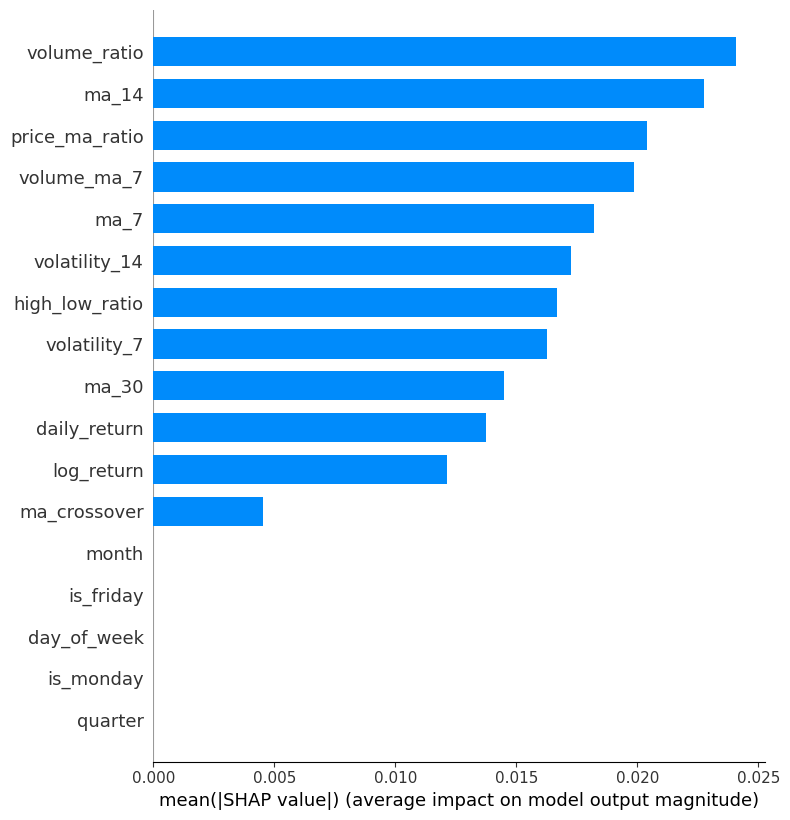

In [288]:
# Global Feature Importance Chart

shap.summary_plot(
    shap_values_class1,
    X_test_scaled,
    feature_names=feature_columns,
    plot_type="bar"
)

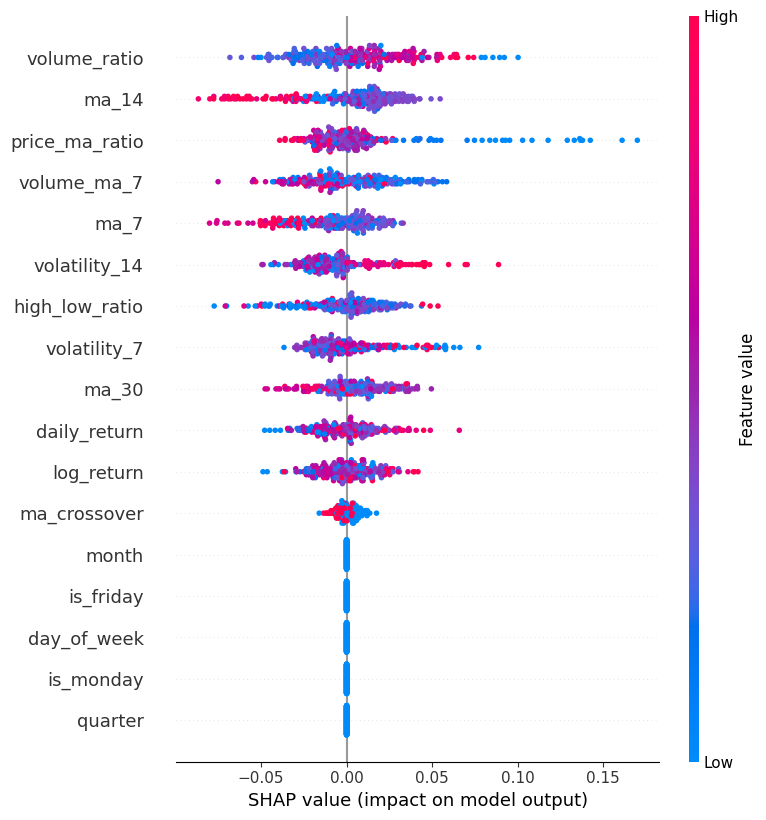

In [289]:
# SHAP Summary Dot Plot

shap.summary_plot(
    shap_values_class1,
    X_test_scaled,
    feature_names=feature_columns
)

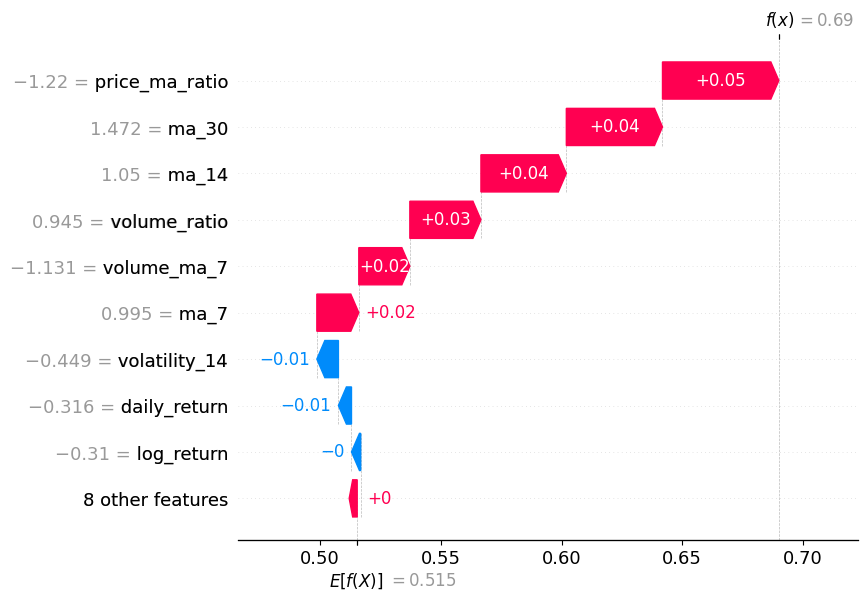

In [290]:
# Waterfall Plot

sample = 5

explanation = shap.Explanation(

    values=shap_values_class1[sample],

    base_values=explainer.expected_value[1],

    data=X_test_scaled[sample],

    feature_names=feature_columns

)

shap.waterfall_plot(explanation)

In [291]:
# Force Plot

shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1[sample],
    X_test_scaled[sample],
    feature_names=feature_columns,
    matplotlib=False
)

###Task 11: Building RAG Pipeline

In [292]:
!pip install chromadb langchain-text-splitters sentence-transformers

# ===============================
# Preparing the News for RAG
# ===============================

# Importing Libraries

from sentence_transformers import SentenceTransformer
import chromadb
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [293]:
# Creating a Dictionary for News Text

news_documents = {}

In [294]:
# Converting Each News CSV into One Text Document

for ticker, df in news_data.items():

    print(f"Preparing news for {ticker}...")

    # Replace missing values with empty strings
    df = df.fillna("")

    # Combine important columns into one text
    combined_text = ""

    for _, row in df.iterrows():

        article = f"""
Title: {row['title']}

Description: {row['description']}

Content: {row['content']}
"""

        combined_text += article + "\n\n"

    news_documents[ticker] = combined_text

print("\nNews documents created successfully!")

Preparing news for ^BSESN...
Preparing news for RELIANCE.NS...
Preparing news for TCS.NS...
Preparing news for INFY.NS...
Preparing news for HDFCBANK.NS...

News documents created successfully!


In [295]:
# Verifying One Document

print(news_documents["RELIANCE.NS"][:1000])


Title: Mukesh Ambani’s long game: How Reliance could turn a 3-year spending spree into Rs 90,000 crore of free cash flow

Description: Reliance Industries could generate nearly Rs 90,000 crore in cumulative free cash flow over FY26-FY28 as its heavy investment cycle eases, brokerages say. Stronger earnings from energy and Jio, coupled with moderating capex, may reduce leverage and mark the b…

Content: Billionaire Mukesh Ambanis three-year investment binge may finally be approaching its payoff phase. Reliance Industries, which operated with materially negative free cash flow during the period, coul… [+6264 chars]



Title: 12 stocks that Goldman Sachs, Axis, InCred Equities are bullish on. Here’s the full list

Description: Leading brokerage firms have identified twelve Indian stocks for investment. Goldman Sachs favors Reliance Industries and Adani Power among others. InCred Equities sees significant upside in APAR Industries and CONCOR. Axis Bank has also recommended Chalet Ho…

Con

In [296]:
# Splitting into Chunks

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)

# Chunk All Documents

news_chunks = {}

for ticker, text in news_documents.items():

    chunks = text_splitter.split_text(text)

    news_chunks[ticker] = chunks

    print(f"{ticker}: {len(chunks)} chunks")

^BSESN: 27 chunks
RELIANCE.NS: 38 chunks
TCS.NS: 34 chunks
INFY.NS: 27 chunks
HDFCBANK.NS: 31 chunks


In [297]:
# Verify

news_chunks["RELIANCE.NS"][0]

'Title: Mukesh Ambani’s long game: How Reliance could turn a 3-year spending spree into Rs 90,000 crore of free cash flow\n\nDescription: Reliance Industries could generate nearly Rs 90,000 crore in cumulative free cash flow over FY26-FY28 as its heavy investment cycle eases, brokerages say. Stronger earnings from energy and Jio, coupled with moderating capex, may reduce leverage and mark the b…'

In [298]:
# ================================
# Create Embeddings
# ================================

# Installing the library
!pip install -q sentence_transformers

from sentence_transformers import SentenceTransformer
import numpy as np

# Creating the Function

def create_embeddings(chunks, model_name="all-MiniLM-L6-v2"):

    """
    Creates embeddings for a list of chunks
    and returns them as a list of lists.
    """

    # Loading Sentence Transformer model
    model = SentenceTransformer(model_name)

    # Creating embeddings
    embeddings = model.encode(
        chunks,
        convert_to_numpy=True
    )

    # Convert NumPy array to list
    embeddings = embeddings.tolist()

    return embeddings



In [299]:
# Creating Embeddings for Every Stock

news_embeddings = {}

for ticker, chunks in news_chunks.items():

    print(f"Creating embeddings for {ticker}...")

    embeddings = create_embeddings(chunks)

    news_embeddings[ticker] = embeddings

print("\nAll embeddings created successfully!")

Creating embeddings for ^BSESN...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Creating embeddings for RELIANCE.NS...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Creating embeddings for TCS.NS...


...

Creating embeddings for INFY.NS...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Creating embeddings for HDFCBANK.NS...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


All embeddings created successfully!


In [300]:
# Verification

print("Total Embeddings:", len(news_embeddings["RELIANCE.NS"]))

print()

print(
    "Embedding Dimension:",
    len(news_embeddings["RELIANCE.NS"][0])
)

embeddings_array = np.array(
    news_embeddings["RELIANCE.NS"]
)

print()

print("Embedding Shape:", embeddings_array.shape)

print()

print("First 10 values")

print("-"*50)

print(news_embeddings["RELIANCE.NS"][0][:10])

Total Embeddings: 38

Embedding Dimension: 384

Embedding Shape: (38, 384)

First 10 values
--------------------------------------------------
[-0.06191569194197655, 0.014264513738453388, -0.025329073891043663, 0.02066492848098278, 0.03986514359712601, -0.06922879815101624, 0.03568281605839729, 0.03415592014789581, 0.005438784137368202, 0.054589614272117615]


In [301]:
# ======================================
# Building the Vector Search (Retriever)
# ======================================

# Import Cosine Similarity

from sklearn.metrics.pairwise import cosine_similarity

# Creating Retrieval Function

def retrieve_news(query, ticker, top_k=3):

    # Load embedding model
    model = SentenceTransformer("all-MiniLM-L6-v2")

    # Embed the query
    query_embedding = model.encode(
        [query],
        convert_to_numpy=True
    )

    # Convert stored embeddings to NumPy array
    chunk_embeddings = np.array(news_embeddings[ticker])

    # Calculate similarity
    similarities = cosine_similarity(
        query_embedding,
        chunk_embeddings
    )[0]

    # Top K most similar chunks
    top_indices = similarities.argsort()[-top_k:][::-1]

    retrieved_chunks = [
        news_chunks[ticker][i]
        for i in top_indices
    ]

    return retrieved_chunks

In [302]:
# Testing the Retriever

retrieved = retrieve_news(
    query="Why did Reliance stock rise?",
    ticker="RELIANCE.NS",
    top_k=3
)

for i, chunk in enumerate(retrieved, start=1):

    print("=" * 80)

    print(f"Chunk {i}")

    print("=" * 80)

    print(chunk)

    print()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Chunk 1
Content: Shares of Mukesh Ambani-led Reliance Industries rose over a per cent to Rs 1,342 on the BSE on Monday after the conglomerate reported June quarter earnings that topped street expectations on the back… [+5396 chars]



Title: Stocks in news: ICICI Bank, YES Bank, Kotak Bank, RIL, Axis Bank

Chunk 2
Content: Billionaire Mukesh Ambanis three-year investment binge may finally be approaching its payoff phase. Reliance Industries, which operated with materially negative free cash flow during the period, coul… [+6264 chars]



Title: 12 stocks that Goldman Sachs, Axis, InCred Equities are bullish on. Here’s the full list

Chunk 3
Content: Reliance Industries (RIL) posted a 25% decline in consolidated net profit for the June quarter, as earnings in the year-ago period had been boosted by a one-time exceptional gain from the sale of its… [+3629 chars]



Title: Reliance Industries Q1 FY27: Oil-to-Chemicals EBITDA rises 17%; solar and battery manufacturing plans advance



In [303]:
# Testing Different Questions

retrieve_news(
    "Summarize Infosys earnings",
    "INFY.NS"
)

retrieve_news(
    "Banking sector news",
    "HDFCBANK.NS"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

['Content: The shares of five heavyweight private lenders including HDFC Bank, Yes Bank, ICICI Bank, Kotak Mahindra Bank and Axis Bank reacted strongly to their Q1 earnings on Monday, with brokerages highlighti… [+4446 chars]\n\n\n\nTitle: Cause for concern? HDFC Bank is lagging ICICI Bank where it matters as investors count Rs 5 lakh crore loss',
 'Content: HDFC Bank is facing fresh scrutiny in the United States, with three separate US law firms announcing investigations into whether the lender violated federal securities laws. This widens the fallout f… [+2681 chars]\n\n\n\nTitle: Interest certificate download: How SBI, HDFC Bank, Axis Bank and India Post customers can get it online',
 'Description: and Axis Bank, two of India’s largest private-sector banks, both posted steep losses on Monday amid concerns about contracting NIMs (net interest margins), a key profitability metric in the banking industry.\nIn the case of HDFC Bank, whose ADRs (American Depo…\n\nContent: and Axis Bank, 

In [304]:
# =====================================
# Building the RAG Chatbot
# =====================================

!pip install -q cohere

import cohere

In [305]:
def ask_rag(question, ticker, api_key):

    # Retrieve relevant news chunks
    retrieved_chunks = retrieve_news(
        query=question,
        ticker=ticker,
        top_k=3
    )

    # Create Cohere client
    co = cohere.ClientV2(api_key)

    # Combine retrieved chunks
    context = "\n\n".join(retrieved_chunks)

    # Prompt
    prompt = f"""
Use ONLY the context below to answer the question.

Context:
{context}

Question:
{question}
"""

    # Generate response
    response = co.chat(

        model="command-a-03-2025",

        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.message.content[0].text

In [306]:
# Testing

from google.colab import userdata
COHERE_API_KEY = userdata.get('Cohere_API')

answer = ask_rag(

    question="Why did Reliance stock rise?",

    ticker="RELIANCE.NS",

    api_key=COHERE_API_KEY

)

print(answer)

print(
    ask_rag(
        "Summarize Infosys news",
        "INFY.NS",
        COHERE_API_KEY
    )
)

print(
    ask_rag(
        "What happened in HDFC Bank?",
        "HDFCBANK.NS",
        COHERE_API_KEY
    )
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Reliance Industries' stock rose over a percent to Rs 1,342 on the BSE on Monday because the conglomerate reported June quarter earnings that topped street expectations.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Infosys reported its Q1 results, with revenue rising 2.8% year-over-year to $5 billion, slightly below expectations in both dollar and rupee terms. The company trimmed its FY27 revenue growth guidance to 1.5%-3%, citing persistent macro uncertainty. Following the announcement, Infosys shares fell over 2%, hitting a low of ₹1,023 on the NSE, and global brokerages issued bearish calls, reducing their target prices for the stock.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

HDFC Bank is facing fresh scrutiny in the United States, with three separate US law firms announcing investigations into whether the lender violated federal securities laws. Additionally, the bank's shares extended losses for a second straight session after its Q1 FY27 earnings, falling 1.5% to Rs 766, despite brokerages retaining bullish ratings. The investigations are reportedly related to alleged Maharashtra deposit payments.


In [307]:
print(news_data["RELIANCE.NS"][["title"]].head(10))

                                               title
0  Mukesh Ambani’s long game: How Reliance could ...
1  12 stocks that Goldman Sachs, Axis, InCred Equ...
2  Market wrap: Top gainers and losers on Nifty a...
3  RIL sees better global refining margins despit...
4  Q1 Results Today Highlights: UltraTech profit ...
5  Reliance Industries share price target: What a...
6  Stocks in news: ICICI Bank, YES Bank, Kotak Ba...
7  Refining gains, clean energy push lift Relianc...
8  Reliance Industries' FMCG business turns EBITD...
9  M-cap of five of top 10 most valued firms jump...


###Task 12: Create Streamlit App

In [308]:
!pip install -q streamlit


In [3]:
%%writefile app.py

import os
import streamlit as st
import pandas as pd
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import shap
import matplotlib.pyplot as plt
import cohere
import numpy as np

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from langchain_text_splitters import RecursiveCharacterTextSplitter

COHERE_API_KEY = "YOUR_COHERE_API_KEY"

# ======================================================
# LOAD EMBEDDING MODEL
# ======================================================

@st.cache_resource
def load_embedding_model():
    return SentenceTransformer("all-MiniLM-L6-v2")

embedding_model = load_embedding_model()

# ======================================================
# LOAD NEWS FILES
# ======================================================

@st.cache_data
def load_news():

    assets = [
        "^BSESN",
        "RELIANCE.NS",
        "TCS.NS",
        "INFY.NS",
        "HDFCBANK.NS"
    ]

    news_data = {}

    for ticker in assets:

       filename = f"news/news_{ticker}.csv"

    if os.path.exists(filename):

          df = pd.read_csv(filename)

          news_data[ticker] = df

          return news_data


news_data = load_news()

# ======================================================
# CLEAN NEWS DATA
# ======================================================

for ticker, df in news_data.items():

    if "publishedAt" in df.columns:
        df["publishedAt"] = pd.to_datetime(
            df["publishedAt"],
            errors="coerce"
        )

    df.drop_duplicates(inplace=True)

    for col in ["title", "description", "content"]:

        if col in df.columns:
            df[col] = df[col].fillna("")

    news_data[ticker] = df

# ======================================================
# CREATE DOCUMENTS
# ======================================================

news_documents = {}

for ticker, df in news_data.items():

    document = ""

    for _, row in df.iterrows():

        article = f"""
Title: {row['title']}

Description:
{row['description']}

Content:
{row['content']}

"""

        document += article + "\n"

    news_documents[ticker] = document

# ======================================================
# CREATE CHUNKS
# ======================================================

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)

news_chunks = {}

for ticker, text in news_documents.items():

    chunks = text_splitter.split_text(text)

    news_chunks[ticker] = chunks

# ======================================================
# CREATE EMBEDDINGS
# ======================================================

news_embeddings = {}

for ticker, chunks in news_chunks.items():

    embeddings = embedding_model.encode(
        chunks,
        convert_to_numpy=True
    )

    news_embeddings[ticker] = embeddings


# ======================================================
# RETRIEVER
# ======================================================

def retrieve_news(query, ticker, top_k=3):

    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True
    )

    similarities = cosine_similarity(
        query_embedding,
        news_embeddings[ticker]
    )[0]

    top_indices = similarities.argsort()[-top_k:][::-1]

    retrieved_chunks = [
        news_chunks[ticker][i]
        for i in top_indices
    ]

    return retrieved_chunks

# ======================================================
# RAG FUNCTION
# ======================================================

def ask_rag(question, ticker, api_key):

    retrieved_chunks = retrieve_news(
        question,
        ticker
    )

    context = "\n\n".join(retrieved_chunks)

    co = cohere.ClientV2(api_key)

    prompt = f"""
Use ONLY the context below to answer the question.

Context:
{context}

Question:
{question}
"""

    response = co.chat(

        model="command-a-03-2025",

        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.message.content[0].text


# ======================================================
# PAGE CONFIG
# ======================================================

st.set_page_config(
    page_title="Stock Market Intelligence System",
    page_icon="📈",
    layout="wide"
)

# ======================================================
# TITLE
# ======================================================

st.title("📈 Stock Market Intelligence System")

st.write("Capstone Project")

# ======================================================
# SIDEBAR
# ======================================================

st.sidebar.title("Asset Selection")

assets = [
    "^BSESN",
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS"
]

selected_asset = st.sidebar.selectbox(
    "Choose an Asset",
    assets
)

st.sidebar.success(f"Selected: {selected_asset}")


# ======================================================
# TABS
# ======================================================

tab1, tab2, tab3 = st.tabs(
    [
        "📈 Predictions",
        "💬 Chat",
        "📊 Comparison"
    ]
)

# ======================================================
# TAB 1 : Prediction
# ======================================================

with tab1:

    st.header("Predictions")

    st.subheader(f"Selected Asset : {selected_asset}")

    # Load stock data
    file_name = f"data/data_{selected_asset}.csv"

    df = pd.read_csv(file_name)

    # Convert Date column
    df["Date"] = pd.to_datetime(df["Date"])

    # Price Chart
    fig = px.line(
        df,
        x="Date",
        y="Close",
        title=f"{selected_asset} Closing Price"
    )

    st.plotly_chart(fig, use_container_width=True)

    # ---------------------------------------
    # Feature Engineering
    # ---------------------------------------

    df["ma_7"] = df["Close"].rolling(7).mean()
    df["ma_30"] = df["Close"].rolling(30).mean()

    df["target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

    df = df.dropna()

    feature_columns = ["Close","Volume","ma_7","ma_30"]

    X = df[feature_columns]
    y = df["target"]

    # ---------------------------------------
    # Scale Data
    # ---------------------------------------

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    # ---------------------------------------
    # Train Model
    # ---------------------------------------

    model = RandomForestClassifier(n_estimators=100, random_state=42)

    model.fit(X_scaled, y)

    # ---------------------------------------
    # Predict Latest Day
    # ---------------------------------------

    latest = X_scaled[-1].reshape(1, -1)

    prediction = model.predict(latest)[0]

    confidence = model.predict_proba(latest)[0].max()

    # ---------------------------------------
    # SHAP Explainer
    # ---------------------------------------

    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X_scaled)

    st.subheader("Prediction")

    if prediction == 1:
        st.success("📈 Prediction : UP")
    else:
        st.error("📉 Prediction : DOWN")

    st.metric(
        "Confidence Score",
        f"{confidence*100:.2f}%"
    )

    # ---------------------------------------
    # SHAP Feature Importance
    # ---------------------------------------

    st.subheader("SHAP Feature Importance")

    fig = plt.figure(figsize=(10,6))

    shap.summary_plot(
        shap_values[:, :, 1],
        X_scaled,
        feature_names=feature_columns,
        plot_type="bar",
        show=False
    )

    st.pyplot(fig)
    plt.close(fig)

    # ---------------------------------------
    # SHAP Waterfall Plot
    # ---------------------------------------

    st.subheader("SHAP Waterfall Plot")

    sample = -1

    # SHAP values for Class 1 (UP)
    sample_shap = shap_values[sample][:, 1]

    explanation = shap.Explanation(
        values=sample_shap,
        base_values=explainer.expected_value[1],
        data=X_scaled[sample],
        feature_names=feature_columns
    )

    fig = plt.figure(figsize=(8,6))

    shap.plots.waterfall(
        explanation,
        show=False
    )

    st.pyplot(fig)
    plt.close(fig)



# ==========================================================
# TAB 2 : CHAT
# ==========================================================

with tab2:

    st.header("💬 Stock Market Chatbot")

    st.write("Ask questions related to the selected stock.")

    if "messages" not in st.session_state:
        st.session_state.messages = []

    for message in st.session_state.messages:

        with st.chat_message(message["role"]):
            st.markdown(message["content"])

    user_question = st.chat_input("Ask your question...")

    if user_question:

        st.session_state.messages.append(
            {
                "role": "user",
                "content": user_question
            }
        )

        with st.chat_message("user"):
            st.markdown(user_question)

        with st.chat_message("assistant"):

            with st.spinner("Thinking..."):

                answer = ask_rag(
                    user_question,
                    selected_asset,
                    COHERE_API_KEY
                )

                st.markdown(answer)

        st.session_state.messages.append(
            {
                "role": "assistant",
                "content": answer
            }
        )


# ======================================================
# TAB 3 : Comparision
# ======================================================

with tab3:

    st.header("📊 Asset Comparison")

    comparison_data = []

    for asset in assets:

        # -------------------------
        # Load data
        # -------------------------
        df = pd.read_csv(f"data_{asset}.csv")

        df["ma_7"] = df["Close"].rolling(7).mean()
        df["ma_30"] = df["Close"].rolling(30).mean()

        df["target"] = (
            df["Close"].shift(-1) > df["Close"]
        ).astype(int)

        df = df.dropna()

        feature_columns = [
            "Close",
            "Volume",
            "ma_7",
            "ma_30"
        ]

        X = df[feature_columns]
        y = df["target"]

        # -------------------------
        # Scale
        # -------------------------
        scaler = StandardScaler()

        X_scaled = scaler.fit_transform(X)

        # -------------------------
        # Train Model
        # -------------------------
        model = RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )

        model.fit(X_scaled, y)

        # -------------------------
        # Latest Prediction
        # -------------------------
        latest = X_scaled[-1].reshape(1, -1)

        prediction = model.predict(latest)[0]

        confidence = model.predict_proba(latest)[0].max()

        prediction_text = "UP" if prediction == 1 else "DOWN"

        comparison_data.append({

            "Asset": asset,
            "Close": round(df["Close"].iloc[-1], 2),
            "Volume": int(df["Volume"].iloc[-1]),
            "ma_7": round(df["ma_7"].iloc[-1], 2),
            "ma_30": round(df["ma_30"].iloc[-1], 2),
            "Prediction": prediction_text,
            "Confidence": round(confidence * 100, 2)

        })

    comparison_df = pd.DataFrame(comparison_data)

    # ======================================================
    # COMPARISON TABLE
    # ======================================================

    st.subheader("Comparison Table")

    st.dataframe(
        comparison_df,
        use_container_width=True,
        hide_index=True
    )

    # ======================================================
    # BAR CHART OF METRICS
    # ======================================================

    st.subheader("Bar Chart of Metrics")

    metric = st.selectbox(
        "Select Metric",
        [
            "Close",
            "Volume",
            "ma_7",
            "ma_30",
            "Confidence"
        ]
    )

    fig = px.bar(
        comparison_df,
        x="Asset",
        y=metric,
        color="Asset",
        title=f"{metric} Comparison"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    # ======================================================
    # PREDICTION COMPARISON
    # ======================================================

    st.subheader("Prediction Comparison")

    prediction_colors = []

    for pred in comparison_df["Prediction"]:

        if pred == "UP":
            prediction_colors.append("🟢 UP")
        else:
            prediction_colors.append("🔴 DOWN")

    prediction_display = comparison_df[["Asset"]].copy()

    prediction_display["Prediction"] = prediction_colors

    st.dataframe(
        prediction_display,
        use_container_width=True,
        hide_index=True
    )

Overwriting app.py


In [4]:
# downloading app.py

from google.colab import files
files.download('app.py')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

####Thank you for your time and consideration

####This project has been a valuable learning experience, and I'm excited to apply these skills further.

~ Prepared and Developed by - Mohammad Daarim Javed



---

